# Import Packages

In [1]:
from glob import glob
import random
import warnings
from cmcrameri import cm
import numpy as np
from IPython.display import display
from pathlib import Path
from pandas import DataFrame, concat, read_parquet
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable
from matplotlib.figure import Figure
from matplotlib.lines import Line2D
import matplotlib.colors as mcolors
import re
import contextily as ctx
import geopandas as gpd
import pydeck as pdk

import func_gev as gev
import func_preparation as dbf
import func_plotting as dbplt
import func_utils as ut

warnings.filterwarnings("ignore", category=FutureWarning)
%matplotlib inline
CMAP = cm.managua_r

fs = 12

# Settings

In [2]:
path_data = '../input/Annual_max_DCPP_20260112/'
path_export = '../output/exploration/'

dir_results = '../output/gev_analysis/2026-03-20/'
dir_data_pkl = '../output/gev_analysis/2026-03-20/data.parquet'

In [3]:
HINDCAST_START = 1960
HINDCAST_END = 2026

In [4]:
axes_color: str = '#333333'
markers_color: str = "#99E3DDFF"
colors_reg: list = ['#333333FF', '#7F6C7BFF']  

In [5]:
RETURN_PERIODS = [10, 25, 50, 100, 200]
PLOT_PERIOD_EVOLUTION = ['10-year', '50-year', '100-year']

In [6]:
CONFIDENCE_INTERVAL = 0.9 # two-side 90% CI interval (5% each side)

In [7]:
# adding a little randomness to enhance trust the model works as robust as possible cross locations..
start_location = 0 #random.choice(arange(0, 9579))
end_location = 2000 #start_location+10

print(f'analyse a subsample of location {start_location}–{end_location}')

analyse a subsample of location 0–2000


# Import Data

### Import Raw Data from Models

In [ ]:
ls_files = [file for file in glob(path_data + '*.nc')]
ls_files

In [ ]:
dic_data_per_model = dbf.import_all_models(ls_files)

### Import regression results for location trend regression

In [8]:
[
    results_annual_stat_all, results_nonstat_all, location_geo_info, location_point_info
    ] = ut.import_info_for_regression(dir_results)

loading ../output/gev_analysis/2026-03-20//stationary_per_year.pkl
loading ../output/gev_analysis/2026-03-20//nonstationary.pkl
loading ../output/gev_analysis/2026-03-20//LatLon.pkl
loading ../output/gev_analysis/2026-03-20//location_info.pkl


In [9]:
results_stat_all = ut.import_pickle_data(dir_results, 'stationary.pkl')

loading ../output/gev_analysis/2026-03-20//stationary.pkl


In [10]:
raw_data = read_parquet(dir_results + 'data.parquet')

# Data Processing...

### BiasCorrection,...

In [ ]:
dic_data_per_model, combined, notes_overview = dbf.prepare_combined_data(ls_files, dic_data_per_model)

In [ ]:
dic_data_per_location = dbf.extract_location_data(combined, HINDCAST_START, HINDCAST_END)

# VISUALS

## Map of Missing Data

In [ ]:
n_obs_per_location = dbf.get_number_of_observations_per_site(dic_data_per_location)
n_obs_per_location

In [ ]:
df_missing_location, df_valid, fig_map = dbf.create_summary_location_w_missing_data(
    dic_data_per_model=dic_data_per_model, combined=combined, n_obs_per_location=n_obs_per_location, dir_export='output/exploration/'
    )

In [ ]:
display(fig_map)

## μ Regression - Non-stationary vs annual stationary per location

compute with standardized or non-standardized years

##### Compute for 1 Location

In [ ]:
ls_missing = []
loc_id = random.choice(list(results_annual_stat_all.keys()))

print(f'Compute regression analysis for μ₁ for site {loc_id}...')

In [ ]:
if results_nonstat_all[loc_id] is None:
    ls_missing.append(loc_id)
    print(f'Could not process side {loc_id}, NO nonstationary results available (counting {len(ls_missing)})')

years_, dic_trend = gev.prepare_for_regression(    
    annual_stationary=results_annual_stat_all[loc_id], 
    nonstationary=results_nonstat_all[loc_id],
    confidence_level_pc=CONFIDENCE_INTERVAL, factor_m_to_mm=1000,
    years_scaled=True
    ) 

In [ ]:
fig_reg = dbplt.plot_location_regression(
    loc_id, years_, dic_trend, results_annual_stat_all[loc_id], 
    confidence_level_pc=CONFIDENCE_INTERVAL, display_results=True, years_scaled=True,
    axes_color='#333333', markers_color="#99E3DDFF", colors_reg=['#CAA5C2FF', '#005C55FF'], 
    fontsize=12, 
    )

#### Compute for All

In [ ]:
dic_fig_regression = {}
ls_missing = []
for loc_id in results_annual_stat_all.keys():
    if loc_id >= start_location and loc_id <= end_location:
        print(f'processing site {loc_id}...')
        
        if results_nonstat_all[loc_id] is None:
            ls_missing.append(loc_id)
            print(f'Skipping side {loc_id}, no nonstationary results (counting {len(ls_missing)})')
            dic_fig_regression[loc_id] = None
            continue
        
        years_, dic_trend = gev.prepare_for_regression(            
            annual_stationary=results_annual_stat_all[loc_id], nonstationary=results_nonstat_all[loc_id],
            confidence_level_pc=CONFIDENCE_INTERVAL, factor_m_to_mm=1000, years_scaled=True
            ) 

        fig_reg = dbplt.plot_location_regression(
            loc_id, years_, dic_trend, results_annual_stat_all[loc_id], fontsize=12,
            confidence_level_pc=CONFIDENCE_INTERVAL, years_scaled=True,
            axes_color='#333333', markers_color="#99E3DDFF", colors_reg=['#CAA5C2FF',  '#005C55FF'], 
            )
        
        dic_fig_regression[loc_id] = fig_reg

In [ ]:
for loc_id in dic_fig_regression.keys():
    if dic_fig_regression[loc_id]:
        ut.store_location_regression(
            dic_fig_regression[loc_id],loc_id, 
            location_geo_info[loc_id], location_point_info[loc_id], 
            Path('../output/gev_analysis/2026-03-20/')
            )

## Maps of Fit Parameters

### Scale σ parameter

In [ ]:
parameter='scale'
unit = 'm'

threshold_z_outlier = 3

export_path = '../output/gev_analysis/2026-03-24/figures/'

In [ ]:
n = 0 
for approach in ['annual-stationary', 'non-stationary', 'stationary']:
    for mark_outlier in [True, False]:
        for interactive_map in [True, False]:
            min_size = 2000 if interactive_map is True else 2.5
            max_size = 20000 if interactive_map is True else 35
            
            print(f'\nplot combination {n+1} out of 12...')
            print('\tapproach', approach, '| mark_outlier', mark_outlier, '| interactive_map', interactive_map)
            if approach == 'non-stationary':
                df=results_nonstat_all
            elif approach == 'annual-stationary':
                df=results_annual_stat_all
            elif approach == 'stationary':
                df=results_stat_all

            fig_map = dbplt.plot_map_for_parameter(
                approach=approach, parameter=parameter, unit=unit, df=df, location_geo_info=location_geo_info,
                confidence_level_pc=CONFIDENCE_INTERVAL, threshold_z_outlier=threshold_z_outlier, 
                mark_outlier=mark_outlier, interactive_map=interactive_map, cmap=CMAP, 
                min_size=min_size, max_size=max_size, saving_map=True, save_path=export_path, fs=12
                )
            n +=1

### Shape ξ parameter

In [ ]:
parameter='shape'
unit = '1'

threshold_z_outlier = 3

export_path = '../output/gev_analysis/2026-03-24/figures/'

In [ ]:
n = 0 
for approach in ['annual-stationary', 'non-stationary', 'stationary']:
    for mark_outlier in [True, False]:
        for interactive_map in [True, False]:
            min_size = 2000 if interactive_map is True else 2.5
            max_size = 20000 if interactive_map is True else 35
            
            print(f'\nplot combination {n+1} out of 12...')
            print('\tapproach', approach, '| mark_outlier', mark_outlier, '| interactive_map', interactive_map)
            if approach == 'non-stationary':
                df=results_nonstat_all
            elif approach == 'annual-stationary':
                df=results_annual_stat_all
            elif approach == 'stationary':
                df=results_stat_all

            fig_map = dbplt.plot_map_for_parameter(
                approach=approach, parameter=parameter, unit=unit, df=df, location_geo_info=location_geo_info,
                confidence_level_pc=CONFIDENCE_INTERVAL, threshold_z_outlier=threshold_z_outlier, 
                mark_outlier=mark_outlier, interactive_map=interactive_map, cmap=CMAP, 
                min_size=min_size, max_size=max_size, saving_map=True, save_path=export_path, fs=12
                )
            n +=1

### Location μ parameter

In [ ]:
parameter='mu'
unit = 'm'

threshold_z_outlier = 3

export_path = '../output/gev_analysis/2026-03-24/figures/'

In [ ]:
n = 0 
for approach in ['annual-stationary', 'non-stationary', 'stationary']:
    for mark_outlier in [True, False]:
        for interactive_map in [True, False]:
            min_size = 2000 if interactive_map is True else 2.5
            max_size = 20000 if interactive_map is True else 35
            
            print(f'\nplot combination {n+1} out of 12...')
            print('\tapproach', approach, '| mark_outlier', mark_outlier, '| interactive_map', interactive_map)
            if approach == 'non-stationary':
                df=results_nonstat_all
            elif approach == 'annual-stationary':
                df=results_annual_stat_all
            elif approach == 'stationary':
                df=results_stat_all

            fig_map = dbplt.plot_map_for_parameter(
                approach=approach, parameter=parameter, unit=unit, df=df, location_geo_info=location_geo_info,
                confidence_level_pc=CONFIDENCE_INTERVAL, threshold_z_outlier=threshold_z_outlier, 
                mark_outlier=mark_outlier, interactive_map=interactive_map, cmap=CMAP, 
                min_size=min_size, max_size=max_size, saving_map=True, save_path=export_path, fs=12
                )
            n +=1

### Location Trend μ₁

$μ_1$ with the color indicating the absolute value and the size indicating the std of $μ_1$ 

In [ ]:
parameter='mu1'
unit = 'mm/year'

threshold_z_outlier = 3

export_path = '../output/gev_analysis/2026-03-24/figures/'

In [ ]:
n = 0 
for approach in ['annual-stationary', 'non-stationary']:
    for mark_outlier in [True, False]:
        for interactive_map in [True, False]:
            min_size = 2000 if interactive_map is True else 2.5
            max_size = 20000 if interactive_map is True else 35
            
            print(f'\nplot combination {n+1} out of 8...')
            print('\tapproach', approach, '| mark_outlier', mark_outlier, '| interactive_map', interactive_map)
            if approach == 'non-stationary':
                df=results_nonstat_all
            elif approach == 'annual-stationary':
                df=results_annual_stat_all

            fig_map = dbplt.plot_map_for_parameter(
                approach=approach, parameter=parameter, unit=unit, df=df, location_geo_info=location_geo_info,
                confidence_level_pc=CONFIDENCE_INTERVAL, threshold_z_outlier=threshold_z_outlier, 
                mark_outlier=mark_outlier, interactive_map=interactive_map, cmap=CMAP, 
                min_size=min_size, max_size=max_size, saving_map=True, save_path=export_path, fs=12
                )
            n +=1

## Map ReturnPeriod

In [11]:
lw_marker=0.1
edgecolor_marker = None
fontsize = 12
threshold_z_method = 3

mark_outlier = True
parameter = 'return_period_2026'
plot_year = 2026
base_year = 1961

OUTLIER_MARKER_SIZE = 50
OUTLIER_COLOR = [200, 50, 200, 180]

export_path = '../output/gev_analysis/2026-03-24/figures/'

In [ ]:
def get_return_period_for_50yr_event_per_site(loc_id, results_nonstat_all, location_geo_info):
        df_return_period_location = results_nonstat_all[loc_id]['return_period'].drop_duplicates()
        df = DataFrame(location_geo_info[loc_id]).T
        
        n = df_return_period_location.shape[0]

        df_repeated = df.loc[df.index.repeat(n)].reset_index(drop=True)
        df_repeated.columns = ['lat', 'lon']
        df_repeated.index = df_return_period_location.index
        return concat([df_return_period_location, df_repeated], axis=1)

# -----------------------------------------------------------------------
dic_return_period_50yr = {}
for loc_id in results_nonstat_all.keys():
    dic_return_period_50yr[loc_id] = get_return_period_for_50yr_event_per_site(
        loc_id, results_nonstat_all, location_geo_info
        )


In [13]:
def get_return_period_overview(dic_return_period_50yr):
    ls_return_period_50yr_comparison = []
    for loc_id in dic_return_period_50yr.keys():
        lat, lon = dic_return_period_50yr[loc_id]['lat'].unique()[0], dic_return_period_50yr[loc_id]['lon'].unique()[0]
        
        start, end = dic_return_period_50yr[loc_id].index[[0, -1]]
        
        if end == 2024 or end == 2026:
            end = 2023
            
        if HINDCAST_END in dic_return_period_50yr[loc_id].index:
            df_2026 = dic_return_period_50yr[loc_id].loc[HINDCAST_END].filter(like='mean').values[0]
        else:
            df_2026 = None
            
        ls_return_period_50yr_comparison.append([
            lat, lon,
            start, dic_return_period_50yr[loc_id].loc[start].filter(like='mean').values[0], 
            end, dic_return_period_50yr[loc_id].loc[end].filter(like='mean').values[0],
            HINDCAST_END, df_2026
            ])
        
    return DataFrame(
        ls_return_period_50yr_comparison, 
        columns=[
            'lat', 'lon', 
            'base_year', 'return_period_base_year', 
            'end_of_comparison', 'return_period_end_year',
            'present_year', 'return_period_2026'
            ]
        )
    
# ----------------------------------------------------------------------- 
df_return_period_50yr_comparison = get_return_period_overview(dic_return_period_50yr)

In [14]:
df_return_period_50yr_comparison.shape[0] - df_return_period_50yr_comparison.dropna().shape[0]

118

... sites have missing values, either because their simulation does not reach 2026 or the return period could not be computed at all

In [15]:
df_return_period_50yr_comparison[df_return_period_50yr_comparison.end_of_comparison == 1961]

,lat,lon,base_year,return_period_base_year,end_of_comparison,return_period_end_year,present_year,return_period_2026
834,62.143154,-7.518844,1961.0,NaN,1961.0,NaN,2026,NaN
893,62.030461,-7.256454,1961.0,NaN,1961.0,NaN,2026,NaN
957,62.085712,-7.043316,1961.0,NaN,1961.0,NaN,2026,NaN
993,62.035768,-6.935365,1961.0,NaN,1961.0,NaN,2026,NaN


For 4 sites, the return period could not be computed...

Each site should at least have predictions until 2023... plot both, 2026 (for those it is possible) and for 2023

In [16]:
df_return_period_50yr_2026_ = df_return_period_50yr_comparison.return_period_2026.dropna()
df_return_period_50yr_2026 = df_return_period_50yr_comparison.loc[df_return_period_50yr_2026_.index]

df_return_period_50yr_2026 = df_return_period_50yr_2026[df_return_period_50yr_2026.base_year == 1961]

In [17]:
if mark_outlier is True:
    df_return_period_50yr_2026 = ut.mark_outliers_zmethod(
        df_return_period_50yr_2026, 'return_period_2026', threshold=threshold_z_method
        )

Marked 151 outliers using modified Z-score method


### interactive Map

In [ ]:
inital_zoom = 3.5

In [ ]:
df_plot = df_return_period_50yr_2026.copy()
df_plot["marker_size"] = 5000

for suffix in ["",]:
    col = parameter + suffix
    df_plot[col + "_str"] = df_plot[col].map("{:.3f}".format)
        
df_plot["lat_str"] = df_plot["lat"].map("{:.3f}".format)
df_plot["lon_str"] = df_plot["lon"].map("{:.3f}".format)

# ---- Turn Value into Color ----
if mark_outlier:
    df_plot["status"] = df_plot["outliers"].apply(
        lambda x: "invalid (outlier)" if x else "valid"
    )
    data = df_plot.loc[~df_plot["outliers"], parameter]
else:
    data = df_plot[parameter]

min_value = np.nanmin(data)
max_value = np.nanmax(data)
norm = mcolors.Normalize(vmin=min_value, vmax=max_value)

def mu_to_color(val):
    rgba = CMAP(norm(val))
    return [int(255*c) for c in rgba[:3]]
df_plot["color"] = df_plot[parameter].apply(mu_to_color)


if mark_outlier:    
    df_plot["color"] = df_plot.apply(
        lambda row: OUTLIER_COLOR if row["outliers"] else row["color"], axis=1
        )
    df_plot["marker_size"] = df_plot.apply(
        lambda row: 20000 if row["outliers"] else row["marker_size"], axis=1
        )

In [ ]:
# ---- Plotting ----
layer = pdk.Layer(
    "ScatterplotLayer",
    data=df_plot,
    get_position='[lon, lat]',
    get_fill_color="color",
    get_radius="marker_size",
    pickable=True,
)

# ---- View ----
view_state = pdk.ViewState(
    latitude=df_plot["lat"].mean(), longitude=df_plot["lon"].mean(), zoom=inital_zoom,
)

legend_html = dbplt.create_gradient_legend(
    CMAP, norm, threshold_z_method, marker_outlier=mark_outlier, parameter=parameter, unit='yr', width=260, height=15, 
    n_steps=100
)

label_para = parameter + "_str"
status_line = "status: {status}<br>" if mark_outlier else ""

tooltip_html = f"""
    <b>ReturnPeriod of 50-yr event (base {base_year})</b><br>
    Lat: {{lat_str}}<br>
    Lon: {{lon_str}}<br>
    ReturnPeriod in {plot_year}: {{{label_para}}} yr<br>
    {status_line}
"""

dic_tooltip = {
    "html": tooltip_html,
    "style": {
        "backgroundColor": "lightgray",
        "color": axes_color,
        "padding": "8px"
    }
}

deck = pdk.Deck(
    layers=[layer],
    initial_view_state=view_state,
    map_style="https://tiles.openfreemap.org/styles/positron",
    tooltip=dic_tooltip
)

save_dir = Path(export_path)
save_dir.mkdir(parents=True, exist_ok=True) 

if mark_outlier is True:
    file_name = f'Map_ReturnPeriod_of_50yrEvent_in_{plot_year}_markedOutlier'
else:
    file_name = f'Map_ReturnPeriod_of_50yrEvent_in_{plot_year}'
    
full_path = (save_dir / file_name).with_suffix('.html')
print(f"map stored as {full_path}")

deck.to_html(full_path)

with open(full_path, "r", encoding="utf-8") as f:
    html = f.read()

html = re.sub(
    r"<title>.*?</title>",
    f"<title>Map ReturnPeriod</title>",
    html,
    flags=re.IGNORECASE
)
html = html.replace("</body>", legend_html + "\n</body>")

with open(full_path, "w", encoding="utf-8") as f:
    f.write(html)


### static Map

In [ ]:
gdf = gpd.GeoDataFrame(
    df_return_period_50yr_2026, 
    geometry=gpd.points_from_xy(df_return_period_50yr_2026['lon'], df_return_period_50yr_2026['lat']), 
    crs="EPSG:4326"
    )
gdf_web = gdf.to_crs(epsg=3857)

In [ ]:
df = gdf_web.copy()
    
if mark_outlier is True:
    valid = gdf_web.loc[~gdf_web["outliers"], parameter]
    min_value = np.nanmin(valid)
    max_value = np.nanmax(valid)
else:
    max_value = np.nanmax(gdf_web[parameter])
    min_value = np.nanmin(gdf_web[parameter]) 
    
norm = mcolors.Normalize(vmin=min_value, vmax=max_value)
def mu_to_color(val):
    rgba = CMAP(norm(val))
    return [int(255*c) for c in rgba[:3]]

df["color"] = df[parameter].apply(mu_to_color)

df["marker_size"] = 5
if mark_outlier is True:
    df["color"] = df.apply(
        lambda row: OUTLIER_COLOR if row["outliers"] else row["color"], axis=1
        )
    df["marker_size"] = df.apply(
        lambda row: OUTLIER_MARKER_SIZE if row["outliers"] else row["marker_size"], axis=1
        )
    
colors = []
for c in df['color']:
    c_rgba = list(c)
    if len(c_rgba) == 3:
        c_rgba.append(255)
    colors.append([v/255 for v in c_rgba])
colors = np.array(colors)


In [ ]:
fig, ax = plt.subplots(figsize=(8,5))

sc = ax.scatter(
        gdf_web.geometry.x, gdf_web.geometry.y, 
        s=df['marker_size'], c=colors, edgecolor=edgecolor_marker, linewidth=lw_marker
        )

ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, zoom=6)

if mark_outlier:
        legend_elements = [
                Line2D(
                [0], [0], linestyle='None', marker=None, 
                label=f"Marker size ~ uncertainty (high → large)"
                f"\nOutlier marked using modified Z-score (threshold {threshold_z_method:.2f}·σ)"
                )
        ]
        ax.legend(handles=legend_elements, loc='lower right', fontsize=fontsize*0.8, framealpha=0.6)
else:
        legend_elements = [
                Line2D([0], [0], linestyle='None', marker=None, label=f"Marker size ~ uncertainty (high → large)")
                ]
ax.legend(handles=legend_elements, loc='lower right', fontsize=fontsize*0.8, framealpha=0.6)

ax.set_axis_off()
sm = ScalarMappable(cmap=CMAP, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, orientation='vertical', fraction=0.03, pad=0.04)

plt.title(f'Return Period of a 50-year event (base year {base_year}) in {plot_year}', loc='left', fontsize=fontsize)

plt.tight_layout()
plt.show()

In [ ]:
save_dir = Path(export_path)
save_dir.mkdir(parents=True, exist_ok=True)

if mark_outlier is True:
    file_name = f'Map_ReturnPeriod_of_50yrEvent_in_{plot_year}_markedOutlier'
else:
    file_name = f'Map_ReturnPeriod_of_50yrEvent_in_{plot_year}'
    
file_name = (save_dir / file_name).with_suffix('.png')
fig.savefig(file_name, dpi=300, bbox_inches='tight')

## Comparing Return Period Evolution for interesting sites

In [18]:
import seaborn as sns 
sns.set_style('whitegrid')

T_EVAL_BASE = 1961
RETURN_PERIOD_EVAL = 50
fs = 10
confidence_interval_pc = CONFIDENCE_INTERVAL

colors_sites = ['#008A80FF', '#99E3DDFF','#DBC3D6FF', '#B887ADFF'] 
plot_reference = True
ci_level=confidence_interval_pc*100

In [19]:
df_rp_evol = df_return_period_50yr_2026

In [28]:
# minimal return period
ls_site_ids = [df_rp_evol.return_period_2026.idxmin()]

In [29]:
# average return period
target = df_rp_evol.return_period_2026.mean()
n = 1

ls_site_ids.extend(
    df_rp_evol.iloc[(df_rp_evol.return_period_2026 - target).abs().argsort()[:n]].index.to_list()
)

In [30]:
# maximal return period (without being an outlier)
ls_site_ids.extend([df_rp_evol[df_rp_evol.outliers == False].return_period_2026.idxmax()])

In [ ]:
# maximal return period (including outliers)
#ls_site_ids.extend([df_rp_evol.return_period_2026.idxmax()])

In [31]:
rp_per_site = [(loc_id, gev.rp_uncertainty_monte_carlo(
    params=results_nonstat_all[loc_id]['params_hat'], cov=results_nonstat_all[loc_id]['cov'],  
    years=raw_data.sim_year.unique(), mean_year=results_nonstat_all[loc_id]['years_mean'], 
    std_year=results_nonstat_all[loc_id]['years_std'], ref_year=T_EVAL_BASE, T_ref=RETURN_PERIOD_EVAL
    )) for loc_id in ls_site_ids]

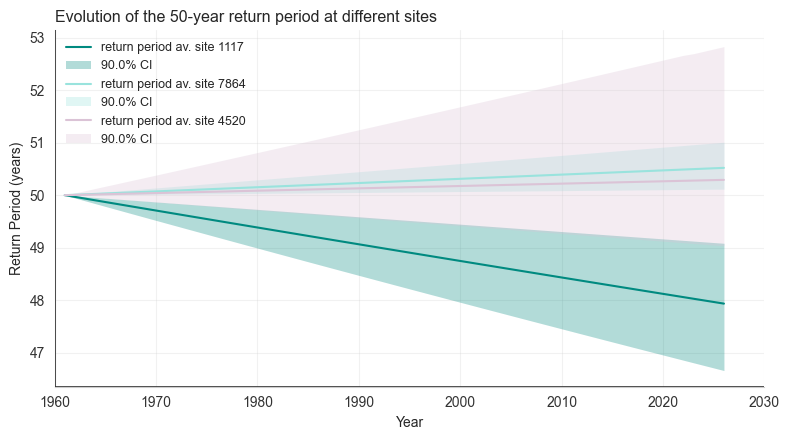

In [32]:
fig, ax = plt.subplots(figsize=(8, 4.5))
for en, return_period_site in enumerate(rp_per_site):
    if en != 0:
        plot_reference = False
    if en > len(colors_sites)+1:
        raise ValueError('Define more colors...')
    
    years = return_period_site[1].index

    if plot_reference is True:
        ax.axhline(
            RETURN_PERIOD_EVAL, color='gray', lw=1, ls='--', alpha=0.6, 
            label=f"Original {RETURN_PERIOD_EVAL}-year event"
            )

    ax.plot(
        return_period_site[1].return_period_median, color=colors_sites[en], 
        label=f"return period av. site {return_period_site[0]}"
        )
    ax.fill_between(
        years, return_period_site[1].return_period_lower.values, 
        return_period_site[1].return_period_upper.values, 
        color=colors_sites[en], alpha=0.3, lw=0, label=f"{ci_level}% CI"
        )

ax.legend(frameon=False, fontsize=fs*0.9)
ax.grid(True, alpha=0.3, color='lightgrey')
for spine in ax.spines.values():
    spine.set_visible(False)

rest_lower = T_EVAL_BASE%10
rest_upper = years[-1]%10
    
ax.set_xlim(T_EVAL_BASE-rest_lower, years[-1]+(10-rest_upper))

ax.axhline(y=ax.get_ylim()[0], color=axes_color, linewidth=1.2, zorder=10)
ax.axvline(x=ax.get_xlim()[0], color=axes_color, linewidth=1.2, zorder=10)
ax.tick_params(axis='x', colors=axes_color)
ax.tick_params(axis='y', colors=axes_color)

ax.set_xlabel('Year', fontsize=fs)
ax.set_ylabel(f'Return Period (years)', fontsize=fs)
ax.set_title(
    f'Evolution of the {RETURN_PERIOD_EVAL}-year return period at different sites', fontsize=fs*1.15, loc='left'
)

sns.despine(ax=ax)  
plt.tight_layout()